# Spline SPF Injection-Recovery Test

This notebook validates that the `InterpolatedUnivariateSpline_SPF` formalism can accurately recover a known Henyey-Greenstein (HG) scattering phase function from a synthetic disk image.

**Strategy:**
1. *Inject* — generate a synthetic disk image using a known HG SPF (g = 0.3).
2. *Recover* — fit the same disk using the spline SPF, holding all geometry fixed, optimising the knot values and `flux_scaling` jointly.
3. *Compare* — plot the recovered spline SPF against the normalised true HG (`HG(cos φ) / HG(0)`) and quantify the agreement.

We repeat the test for **four inclinations** (30°, 50°, 70°, 80°). Higher inclination → wider range of sampled scattering angles → better recovery.

**Normalisation:** The spline is normalised to 1 at 90° (cos φ = 0), so SPF comparisons are always against the normalised HG. The absolute flux amplitude is folded into `flux_scaling`, which is also a free parameter in the fit.

**Initial `flux_scaling`:** Because the spline is normalised to 1 at 90°, the correct starting value is `FLUX × HG(90°)`. In this injection-recovery test we know the truth and can use this directly. With real data a user would supply a physically motivated estimate (e.g. derived from stellar brightness, grain albedo, and system geometry).

**Knot placement:** uniformly spaced across the full cos φ ∈ [−1, 1] (0°–180°). Only the disk's probed range is constrained by data; knots outside it remain near their flat initial value.

In [1]:
import os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import (
    DustEllipticalDistribution2PowerLaws,
    HenyeyGreenstein_SPF,
    InterpolatedUnivariateSpline_SPF,
)
from grater_jax.disk_model.objective_functions import objective_model, Parameter_Index
from grater_jax.optimization.optimize_framework import Optimizer

PLOT_DIR = "spline_recovery_plots"
os.makedirs(PLOT_DIR, exist_ok=True)
print("Output directory:", PLOT_DIR)

2026-03-26 16:25:38.398163: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Output directory: spline_recovery_plots


## True (injected) parameters

In [2]:
G_TRUE    = 0.3
hg_at_90  = float((1.0 / (4.0 * np.pi)) * (1 - G_TRUE**2) / (1 + G_TRUE**2)**1.5)
print(f"HG(cos phi=0, g={G_TRUE}) = {hg_at_90:.6f}")

NX, NY    = 140, 140
FLUX      = 1e6
NUM_KNOTS = 6     # 6 knots is usually enough for smooth SPFs; reduces parameter count
FIT_ITERS = 2000

BASE_MISC = Parameter_Index.misc_params.copy()
BASE_MISC.update({
    "nx": NX, "ny": NY,
    "distance": 50.0,
    "pxInArcsec": 0.01225,
    "halfNbSlices": 25,
    "flux_scaling": FLUX,
})

BASE_DISK = Parameter_Index.disk_params.copy()
BASE_DISK.update({
    "sma": 46.0, "alpha_in": 5.0, "alpha_out": -5.0,
    "ksi0": 1.0, "gamma": 2.0, "beta": 1.0,
    "e": 0.0, "dens_at_r0": 1.0,
    "position_angle": 0.0, "omega": 0.0,
    "x_center": NX / 2, "y_center": NY / 2,
    "halfNbSlices": 25,
})

HG_SPF_PARAMS = HenyeyGreenstein_SPF.params.copy()
HG_SPF_PARAMS["g"] = G_TRUE

INCLINATIONS = [30.0, 50.0, 70.0, 80.0]

HG(cos phi=0, g=0.3) = 0.063634


## Helpers

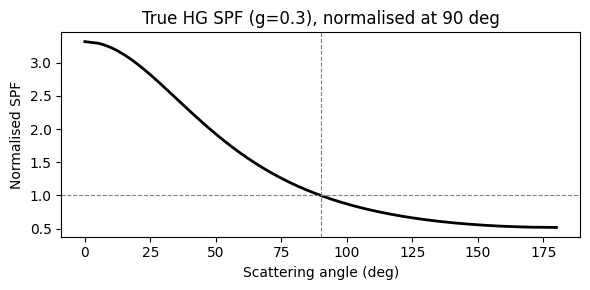

In [3]:
def hg_normalized(cos_phi, g):
    """HG phase function normalised to 1 at cos_phi=0 (90 deg)."""
    raw  = (1.0 / (4.0 * np.pi)) * (1 - g**2) / (1 + g**2 - 2*g*cos_phi)**1.5
    norm = (1.0 / (4.0 * np.pi)) * (1 - g**2) / (1 + g**2)**1.5
    return raw / norm

def probed_cosphi_range(incl_deg):
    """cos(phi) range sampled by a disk at a given inclination.
    Scattering angles range from ~(90-incl) to ~(90+incl) degrees,
    so cos(phi) spans [-sin(incl), +sin(incl)].
    """
    s = np.sin(np.radians(incl_deg))
    return -s, s  # (cp_back, cp_fwd)

assert abs(hg_normalized(0.0, G_TRUE) - 1.0) < 1e-12

cos_grid = np.linspace(-1.0, 1.0, 500)
angles   = np.degrees(np.arccos(cos_grid))

plt.figure(figsize=(6, 3))
plt.plot(angles, hg_normalized(cos_grid, G_TRUE), "k-", lw=2)
plt.axhline(1.0, color="grey", ls="--", lw=0.8)
plt.axvline(90,  color="grey", ls="--", lw=0.8)
plt.xlabel("Scattering angle (deg)")
plt.ylabel("Normalised SPF")
plt.title(f"True HG SPF (g={G_TRUE}), normalised at 90 deg")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "true_hg_spf.png"), dpi=150)
plt.show()

## Injection-recovery loop

**Fit strategy:** joint optimisation of `knot_values` + `flux_scaling` using L-BFGS-B with analytic JAX gradients.  If the first run terminates early (line-search failure), a warm restart resets the quasi-Newton memory and continues from where it stopped.

Knot x-positions span the full cos φ ∈ [−1, 1]. The fit drives knots within the probed range; knots outside remain near the flat starting value.

In [ ]:
results = {}

JOINT_KEYS      = ["knot_values", "flux_scaling"]
JOINT_LOGSCALED = ["knot_values", "flux_scaling"]
JOINT_ARRAYS    = ["knot_values"]

for incl in INCLINATIONS:
    print(f"\n{'='*55}\nInclination = {incl} deg")
    nk = NUM_KNOTS

    # ── 1. Build truth image ──────────────────────────────────────────────────
    disk_params = BASE_DISK.copy()
    disk_params["inclination"] = incl

    truth_misc = BASE_MISC.copy()
    truth_misc["flux_scaling"] = FLUX

    truth_opt = Optimizer(
        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
        HenyeyGreenstein_SPF, None,
        disk_params, HG_SPF_PARAMS, None, None, truth_misc,
    )
    truth_img = np.array(truth_opt.get_model())
    err_map   = np.ones_like(truth_img) * truth_img.max() * 0.01
    print(f'  Truth image: max={truth_img.max():.4e}  err_map: {err_map.max():.4e}')

    # ── 2. Set up spline optimizer ────────────────────────────────────────────
    spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
    spf_params["num_knots"]    = nk
    spf_params["knot_values"]  = jnp.ones(nk)

    fit_misc = BASE_MISC.copy()
    fit_misc["flux_scaling"]   = FLUX * hg_at_90

    opt = Optimizer(
        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
        InterpolatedUnivariateSpline_SPF, None,
        disk_params, spf_params, None, None, fit_misc,
    )

    nk = opt.spf_params["num_knots"]
    knot_cos = np.array(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params))
    print(f'  Knot cos(phi): {np.round(knot_cos, 3)}')

    # ── 3. Initialise ────────────────────────────────────────────────────────
    # Flat SPF + physically motivated flux_scaling.
    # Because the spline normalises to 1 at 90°, with flat knots the model is:
    #   image ≈ flux_scaling * (disk geometry)
    # The HG truth includes HG(90°) = hg_at_90, so the correct anchor is:
    #   flux_scaling_init = FLUX * hg_at_90
    # With real data, supply a physically motivated estimate (stellar brightness,
    # albedo, geometry), or use one of the OptimizeUtils helper functions.
    opt.spf_params["knot_values"] = jnp.ones(nk)
    opt.misc_params["flux_scaling"] = FLUX * hg_at_90
    joint_bounds = ([np.full(nk, 1e-6), 1e2], [np.full(nk, 1e3), 1e12])
    print(f'  flux_scaling init = {opt.misc_params["flux_scaling"]:.4e}  (= FLUX * HG(90 deg))')

    # ── 4. Joint fit with optional warm restarts ──────────────────────────────
    nit_total = 0
    for pass_num in range(1, 4):           # up to 3 passes
        soln = opt.scipy_bounded_optimize(
            fit_keys=JOINT_KEYS,
            fit_bounds=joint_bounds,
            logscaled_params=JOINT_LOGSCALED,
            array_params=JOINT_ARRAYS,
            target_image=truth_img,
            err_map=err_map,
            use_grad=True, iters=FIT_ITERS, ftol=1e-14, gtol=1e-14,
        )
        nit_total += soln.nit
        status = "converged" if soln.success else soln.message[:40].strip()
        print(f'  Pass {pass_num}: nit={soln.nit}  LL={opt.log_likelihood(truth_img, err_map):.4f}  [{status}]')
        if soln.success:
            break

    print(f'  Total nit={nit_total}  flux_scaling={opt.misc_params["flux_scaling"]:.4e}  (expected {FLUX*hg_at_90:.4e})')

    fitted_img = np.array(opt.get_model())

    # ── 5. Evaluate recovered SPF ─────────────────────────────────────────────
    spline_model = InterpolatedUnivariateSpline_SPF.pack_pars(
        opt.spf_params["knot_values"],
        knots=InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)
    )
    recovered_spf = np.array(
        InterpolatedUnivariateSpline_SPF.compute_phase_function_from_cosphi(
            spline_model, jnp.array(cos_grid)
        )
    )
    true_spf_norm = hg_normalized(cos_grid, G_TRUE)

    cp_back, cp_fwd = probed_cosphi_range(incl)
    in_range = (cos_grid >= cp_back) & (cos_grid <= cp_fwd)
    frac_err = np.abs(recovered_spf[in_range] - true_spf_norm[in_range]) / (np.abs(true_spf_norm[in_range]) + 1e-30)
    max_frac_err = float(frac_err.max())
    print(f'  Max fractional SPF error (probed range): {max_frac_err*100:.2f}%')

    results[incl] = dict(
        truth_img=truth_img, fitted_img=fitted_img, err_map=err_map,
        recovered_spf=recovered_spf, true_spf_norm=true_spf_norm,
        knot_cos=knot_cos, knot_values=np.array(opt.spf_params["knot_values"]),
        flux_scaling=float(opt.misc_params["flux_scaling"]),
        spline_model=spline_model,
        cp_fwd=cp_fwd, cp_back=cp_back, in_range=in_range,
        max_frac_err=max_frac_err, nit_total=nit_total,
    )

    # ── 6. Disk image comparison ──────────────────────────────────────────────
    residual = truth_img - fitted_img
    vmin = np.percentile(truth_img[truth_img > 0], 5)
    vmax = truth_img.max()
    res_lim = np.max(np.abs(residual))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Inclination = {incl} deg", fontsize=13)
    im0 = axes[0].imshow(truth_img,  cmap="inferno", origin="lower", vmin=vmin, vmax=vmax)
    axes[0].set_title("Truth (HG SPF)")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(fitted_img, cmap="inferno", origin="lower", vmin=vmin, vmax=vmax)
    axes[1].set_title("Fitted (Spline SPF)")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    im2 = axes[2].imshow(residual,   cmap="seismic", origin="lower", vmin=-res_lim, vmax=res_lim)
    axes[2].set_title("Residual (Truth - Fit)")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"disk_comparison_incl{int(incl):02d}.png"), dpi=150)
    plt.show()

    # ── 7. SPF comparison ─────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(angles, true_spf_norm, "k-",  lw=2,  label="True HG (normalised)")
    ax.plot(angles, recovered_spf, "C0-", lw=2,  label="Recovered spline")
    ang_fwd  = float(np.degrees(np.arccos(cp_fwd)))
    ang_back = float(np.degrees(np.arccos(cp_back)))
    ax.axvspan(ang_fwd, ang_back, alpha=0.12, color="C0",
               label=f"Probed range ({ang_fwd:.0f} to {ang_back:.0f} deg)")
    knot_angles = np.degrees(np.arccos(np.clip(knot_cos, -1, 1)))
    knot_spf_vals = np.array(
        InterpolatedUnivariateSpline_SPF.compute_phase_function_from_cosphi(
            spline_model, jnp.array(knot_cos)
        )
    )
    ax.scatter(knot_angles, knot_spf_vals, color="C0", zorder=5, s=50, label="Knots")
    ax.axvline(90, color="grey", ls="--", lw=0.8)
    ax.axhline(1.0, color="grey", ls="--", lw=0.8)
    ax.set_xlabel("Scattering angle (deg)")
    ax.set_ylabel("Normalised SPF")
    ax.set_title(f"SPF Recovery  incl={incl} deg  max err={max_frac_err*100:.1f}%")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 180)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"spf_comparison_incl{int(incl):02d}.png"), dpi=150)
    plt.show()

## Summary: SPF recovery across all inclinations

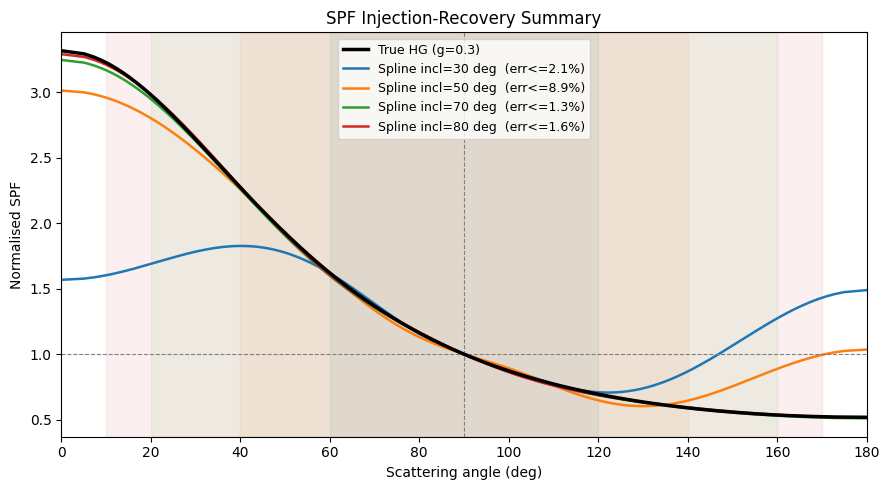


    Inclination    Max SPF error (probed range)
------------------------------------------------
            30 deg                         2.08%
            50 deg                         8.88%
            70 deg                         1.34%
            80 deg                         1.55%


In [5]:
colors = ["C0", "C1", "C2", "C3"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(angles, hg_normalized(cos_grid, G_TRUE), "k-", lw=2.5,
        label=f"True HG (g={G_TRUE})", zorder=10)

for incl, color in zip(INCLINATIONS, colors):
    r = results[incl]
    ax.plot(angles, r["recovered_spf"], "-", color=color, lw=1.8,
            label=f"Spline incl={int(incl)} deg  (err<={r['max_frac_err']*100:.1f}%)")
    ang_fwd  = float(np.degrees(np.arccos(r["cp_fwd"])))
    ang_back = float(np.degrees(np.arccos(r["cp_back"])))
    ax.axvspan(ang_fwd, ang_back, alpha=0.07, color=color)

ax.axvline(90,  color="grey", ls="--", lw=0.8)
ax.axhline(1.0, color="grey", ls="--", lw=0.8)
ax.set_xlabel("Scattering angle (deg)")
ax.set_ylabel("Normalised SPF")
ax.set_title("SPF Injection-Recovery Summary")
ax.legend(fontsize=9)
ax.set_xlim(0, 180)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "spf_recovery_summary.png"), dpi=150)
plt.show()

print()
print(f"{'Inclination':>15}  {'Max SPF error (probed range)':>30}")
print("-" * 48)
for incl in INCLINATIONS:
    print(f"{incl:>14.0f} deg  {results[incl]['max_frac_err']*100:>27.2f}%")

## Fractional residual images

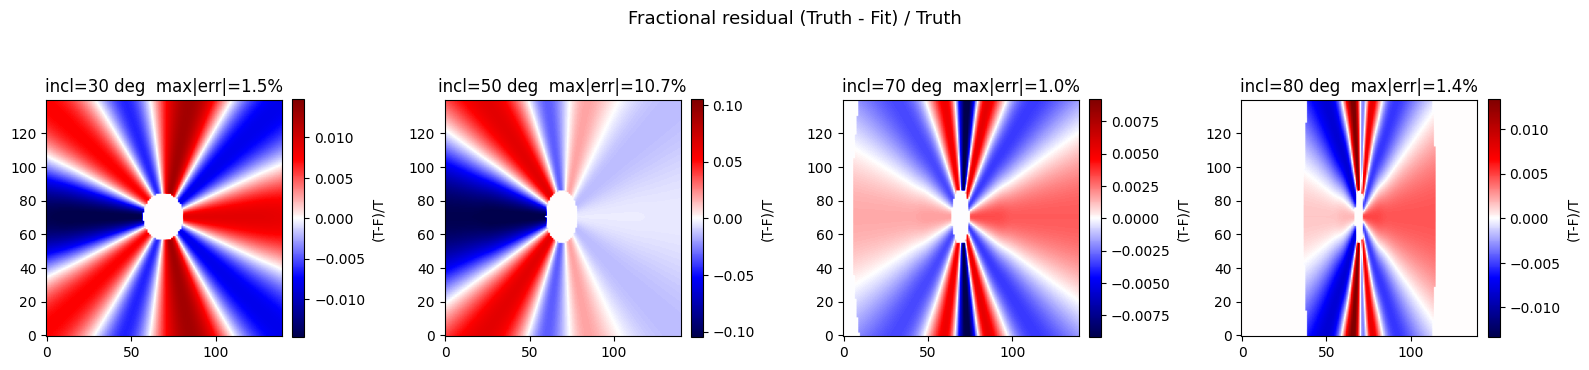

In [6]:
fig, axes = plt.subplots(1, len(INCLINATIONS), figsize=(4*len(INCLINATIONS), 4))

for ax, incl in zip(axes, INCLINATIONS):
    r = results[incl]
    truth   = r["truth_img"]
    bright  = truth > 1e-3 * truth.max()
    frac_resid = np.zeros_like(truth)
    frac_resid[bright] = (truth[bright] - r["fitted_img"][bright]) / truth[bright]
    lim = np.percentile(np.abs(frac_resid[bright]), 99)
    im  = ax.imshow(frac_resid, cmap="seismic", origin="lower", vmin=-lim, vmax=lim)
    max_err_pct = np.abs(frac_resid[bright]).max() * 100
    ax.set_title(f"incl={int(incl)} deg  max|err|={max_err_pct:.1f}%")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="(T-F)/T")

fig.suptitle("Fractional residual (Truth - Fit) / Truth", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "fractional_residuals.png"), dpi=150)
plt.show()

## Interpretation

- **Higher inclination → better recovery.** An 80° disk samples scattering angles from ~10° to ~170°, giving the spline a well-constrained shape across almost the full range. A 30° disk only probes ~60°–120°; knots outside that window remain at their flat initial value and are unconstrained.
- **Recovered ** should converge to approximately  because the spline normalises away the 90° value and transfers it into .
- **Residual structure.** Systematic ring- or spoke-like patterns indicate the spline shape does not yet perfectly match the HG curve over the probed angles. More knots can help at the cost of the fit being more underdetermined outside the probed range.

---

## Full Joint Fit: SPF + Geometry

The previous section held disk geometry fixed, isolating the question of whether the
spline SPF can recover a known HG phase function. In practice a user fitting real data
would optimise the SPF **simultaneously** with at least the basic geometric parameters.

Here we repeat the injection-recovery with a joint fit over five parameters:

| Parameter | Role |
|---|---|
| `knot_values` | Spline SPF shape (6 free values) |
| `flux_scaling` | Absolute brightness scale |
| `inclination` | Disk tilt relative to sky plane |
| `position_angle` | Disk orientation on sky |
| `sma` | Ring semi-major axis |

The fit starts from a **perturbed** initial guess (5° off in inclination and PA, 10% off
in sma) rather than the true values, to simulate a realistic starting condition.
We run two inclinations (50° and 70°) as representative cases.

In [ ]:
# ── Settings ─────────────────────────────────────────────────────────────────
GEOM_INCLINATIONS = [50.0, 70.0]   # subset of INCLINATIONS — joint fits are slower
GEOM_FIT_ITERS    = 3000

GEOM_KEYS      = ["knot_values", "flux_scaling", "inclination", "position_angle", "sma"]
GEOM_LOGSCALED = ["knot_values", "flux_scaling", "sma"]
GEOM_ARRAYS    = ["knot_values"]

# Perturb geometry from truth to simulate a realistic starting condition
INIT_INCL_OFFSET = 5.0   # deg
INIT_PA_OFFSET   = 5.0   # deg
INIT_SMA_FACTOR  = 1.1   # 10% high

geom_results = {}

for incl in GEOM_INCLINATIONS:
    print(f"\n{'='*55}\nInclination = {incl} deg  [joint SPF + geometry]")
    nk = NUM_KNOTS

    # ── 1. Build truth image ──────────────────────────────────────────────────
    true_disk_params = BASE_DISK.copy()
    true_disk_params["inclination"] = incl

    truth_misc = BASE_MISC.copy()
    truth_misc["flux_scaling"] = FLUX

    truth_opt = Optimizer(
        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
        HenyeyGreenstein_SPF, None,
        true_disk_params, HG_SPF_PARAMS, None, None, truth_misc,
    )
    truth_img = np.array(truth_opt.get_model())
    err_map   = np.ones_like(truth_img) * truth_img.max() * 0.01

    # ── 2. Perturbed initial guess ────────────────────────────────────────────
    fit_disk_params = BASE_DISK.copy()
    fit_disk_params["inclination"]    = incl + INIT_INCL_OFFSET
    fit_disk_params["position_angle"] = BASE_DISK["position_angle"] + INIT_PA_OFFSET
    fit_disk_params["sma"]            = BASE_DISK["sma"] * INIT_SMA_FACTOR

    spf_params = InterpolatedUnivariateSpline_SPF.params.copy()
    spf_params["num_knots"]   = nk
    spf_params["knot_values"] = jnp.ones(nk)

    fit_misc = BASE_MISC.copy()
    fit_misc["flux_scaling"] = FLUX * hg_at_90

    opt = Optimizer(
        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
        InterpolatedUnivariateSpline_SPF, None,
        fit_disk_params, spf_params, None, None, fit_misc,
    )

    print(f"  Init: incl={fit_disk_params['inclination']:.1f}  "
          f"PA={fit_disk_params['position_angle']:.1f}  "
          f"sma={fit_disk_params['sma']:.1f}")

    # ── 3. Bounds ─────────────────────────────────────────────────────────────
    geom_bounds = (
        [np.full(nk, 1e-6), 1e2,   0.0, -90.0, 20.0],
        [np.full(nk, 1e3),  1e12, 89.0,  90.0, 100.0],
    )

    # ── 4. Joint fit with warm restarts ───────────────────────────────────────
    nit_total = 0
    for pass_num in range(1, 4):
        soln = opt.scipy_bounded_optimize(
            fit_keys=GEOM_KEYS,
            fit_bounds=geom_bounds,
            logscaled_params=GEOM_LOGSCALED,
            array_params=GEOM_ARRAYS,
            target_image=truth_img,
            err_map=err_map,
            use_grad=True, iters=GEOM_FIT_ITERS, ftol=1e-14, gtol=1e-14,
        )
        nit_total += soln.nit
        status = "converged" if soln.success else soln.message[:40].strip()
        print(f"  Pass {pass_num}: nit={soln.nit}  "
              f"LL={opt.log_likelihood(truth_img, err_map):.4f}  [{status}]")
        if soln.success:
            break

    rec_incl = float(opt.disk_params["inclination"])
    rec_pa   = float(opt.disk_params["position_angle"])
    rec_sma  = float(opt.disk_params["sma"])
    rec_flux = float(opt.misc_params["flux_scaling"])

    print(f"  incl:  recovered={rec_incl:.2f}  truth={incl:.1f}  "
          f"err={abs(rec_incl - incl):.2f} deg")
    print(f"  PA:    recovered={rec_pa:.2f}  truth={BASE_DISK['position_angle']:.1f}  "
          f"err={abs(rec_pa - BASE_DISK['position_angle']):.2f} deg")
    print(f"  sma:   recovered={rec_sma:.2f}  truth={BASE_DISK['sma']:.1f}  "
          f"err={abs(rec_sma - BASE_DISK['sma']):.2f} AU")
    print(f"  flux:  recovered={rec_flux:.4e}  expected={FLUX*hg_at_90:.4e}")

    # ── 5. Recovered SPF ──────────────────────────────────────────────────────
    spline_model = InterpolatedUnivariateSpline_SPF.pack_pars(
        opt.spf_params["knot_values"],
        knots=InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params),
    )
    recovered_spf = np.array(
        InterpolatedUnivariateSpline_SPF.compute_phase_function_from_cosphi(
            spline_model, jnp.array(cos_grid)
        )
    )
    true_spf_norm = hg_normalized(cos_grid, G_TRUE)

    cp_back, cp_fwd = probed_cosphi_range(incl)
    in_range = (cos_grid >= cp_back) & (cos_grid <= cp_fwd)
    frac_err = (np.abs(recovered_spf[in_range] - true_spf_norm[in_range])
                / (np.abs(true_spf_norm[in_range]) + 1e-30))
    max_frac_err = float(frac_err.max())
    print(f"  Max SPF error (probed range): {max_frac_err*100:.2f}%")

    geom_results[incl] = dict(
        truth_img=truth_img,
        fitted_img=np.array(opt.get_model()),
        recovered_spf=recovered_spf,
        true_spf_norm=true_spf_norm,
        cp_fwd=cp_fwd, cp_back=cp_back,
        rec_incl=rec_incl, rec_pa=rec_pa, rec_sma=rec_sma,
        max_frac_err=max_frac_err,
    )

    # ── 6. SPF + geometry summary plot ────────────────────────────────────────
    ang_fwd  = float(np.degrees(np.arccos(cp_fwd)))
    ang_back = float(np.degrees(np.arccos(cp_back)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Joint fit  incl={incl} deg", fontsize=13)

    ax = axes[0]
    ax.plot(angles, true_spf_norm, "k-", lw=2, label="True HG (normalised)")
    ax.plot(angles, recovered_spf, "C1-", lw=2,
            label=f"Recovered spline (err={max_frac_err*100:.1f}%)")
    ax.axvspan(ang_fwd, ang_back, alpha=0.12, color="C1",
               label=f"Probed ({ang_fwd:.0f}–{ang_back:.0f} deg)")
    ax.axvline(90, color="grey", ls="--", lw=0.8)
    ax.axhline(1.0, color="grey", ls="--", lw=0.8)
    ax.set_xlabel("Scattering angle (deg)")
    ax.set_ylabel("Normalised SPF")
    ax.set_title("Scattering phase function")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 180)

    ax = axes[1]
    ax.axis("off")
    table_data = [
        ["Parameter",          "Truth",                           "Recovered",         "Error"],
        ["inclination (deg)",  f"{incl:.1f}",                     f"{rec_incl:.2f}",   f"{abs(rec_incl - incl):.2f}"],
        ["position_angle (deg)", f"{BASE_DISK['position_angle']:.1f}", f"{rec_pa:.2f}", f"{abs(rec_pa - BASE_DISK['position_angle']):.2f}"],
        ["sma (AU)",           f"{BASE_DISK['sma']:.1f}",         f"{rec_sma:.2f}",    f"{abs(rec_sma - BASE_DISK['sma']):.2f}"],
        ["flux_scaling",       f"{FLUX*hg_at_90:.3e}",            f"{rec_flux:.3e}",   "—"],
    ]
    tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                   loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.8)
    ax.set_title("Geometry recovery")

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"joint_fit_incl{int(incl):02d}.png"), dpi=150)
    plt.show()

---

## MCMC Injection-Recovery

Now we repeat the injection-recovery using MCMC to sample the full posterior over `knot_values` and `flux_scaling`.  This verifies that the spline SPF works with Bayesian inference, not just point-estimation, and gives a sense of the posterior uncertainty on the recovered phase function.

**Strategy:**
1. Start from the scipy best-fit result for each inclination (already in `results`).
2. Run emcee with a small ball of walkers around that solution.
3. Extract posterior SPF samples from the chain and plot the ±1σ envelope against the true HG.

MCMC settings are kept modest for speed; increase `NWALKERS` / `NITER` for production.